In [1]:
# general
import numpy as np
from numpy.random import PCG64, SeedSequence
import pandas as pd
import verde as vd
import harmonica as hm
from scipy import interpolate
import xarray as xr
import cmocean
from cmcrameri import cm
import geopandas as gpd
from skgstat import models
import gstatsim as gsm

# plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib import animation

# io
from tqdm.auto import tqdm
import os
from pathlib import Path
import time

import sys
sys.path.append('../../src')

import preprocessing
import block_update
import bouguer
import diagnostics
import rfgen
import utilities
import postprocessing
import gstatsim_custom
import gaussnewton

import importlib
importlib.reload(preprocessing)
importlib.reload(block_update)
importlib.reload(bouguer)
importlib.reload(diagnostics)
importlib.reload(rfgen)
importlib.reload(utilities)
importlib.reload(postprocessing)
importlib.reload(gstatsim_custom)
importlib.reload(gaussnewton)

from preprocessing import *
from block_update import *
from bouguer import *
from diagnostics import *
from rfgen import *
from utilities import *
from postprocessing import *
from gstatsim_custom import *
from gaussnewton import *

In [2]:
bm_path = Path('D:/bedmachine/BedMachineAntarctica-v4.nc')
antgg_path = Path('D:/AntGG2021_allfiles/AntGG2021_Gravity_disturbance_at-surface.nc')

# MOA: https://nsidc.org/data/nsidc-0730/versions/1
moa_base = Path('D:/nsidc0730_MEASURES_MOA2014_v01')

# moa coast and grounding line
moa_coast = gpd.read_file(moa_base/'coastlines/moa2014_coastline_v01.shp')
moa_gl = gpd.read_file(moa_base/'coastlines/moa2014_grounding_line_v01.shp')
moa_island = gpd.read_file(moa_base/'coastlines/moa2014_islands_v01.shp')

glkm = moa_gl.to_crs('+proj=stere +lat_0=-90 +lat_ts=-71 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=km +no_defs +type=crs')
coastkm = moa_coast.to_crs('+proj=stere +lat_0=-90 +lat_ts=-71 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=km +no_defs +type=crs')
islandkm = moa_island.to_crs('+proj=stere +lat_0=-90 +lat_ts=-71 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=km +no_defs +type=crs')

In [3]:
ds = xr.load_dataset(Path('shack.nc'))
ds

<xarray.Dataset> Size: 618kB
Dimensions:       (y: 110, x: 80)
Coordinates:
  * x             (x) float64 640B 2.402e+06 2.408e+06 ... 2.792e+06 2.798e+06
  * y             (y) float64 880B -6.975e+05 -6.925e+05 ... -1.525e+05
Data variables: (12/13)
    bed           (y, x) float32 35kB -66.97 10.26 ... -2.509e+03 -2.729e+03
    surface       (y, x) float32 35kB 1.526e+03 1.487e+03 ... 4.428 4.341
    thickness     (y, x) float32 35kB 1.593e+03 1.477e+03 1.578e+03 ... 0.0 0.0
    mask          (y, x) float64 70kB 2.0 2.0 2.0 2.0 2.0 ... 0.0 0.0 0.0 0.0
    geoid         (y, x) float32 35kB -10.53 -10.52 -10.51 ... 4.517 4.428 4.341
    source        (y, x) float64 70kB 5.0 5.0 5.0 5.0 5.0 ... 10.0 3.0 6.0 10.0
    ...            ...
    errbed        (y, x) float32 35kB 31.0 36.0 63.0 30.0 ... nan 147.0 10.0
    inv_msk       (y, x) bool 9kB False False False False ... False False False
    inv_pad       (y, x) bool 9kB False False False False ... False False False
    grav_surface  (y, x) float64 70kB -16.82 -19.99 -29.34 ... -14.79 -18.14
    grav_1500     (y, x) float64 70kB -15.59 -18.69 -29.39 ... -12.5 -15.61
    stdev         (y, x) float64 70kB 3.085 2.927 2.973 ... 8.497 8.497 8.498
Attributes:
    res:      5000

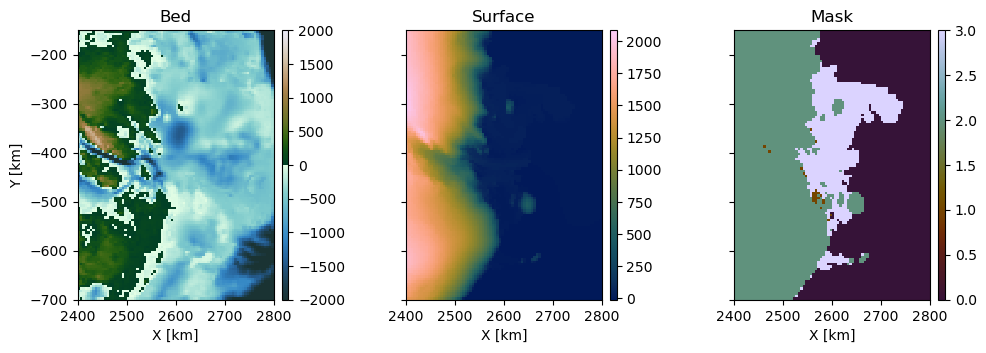

In [4]:
bedmachine_plots(ds, figsize=(12,3.5))

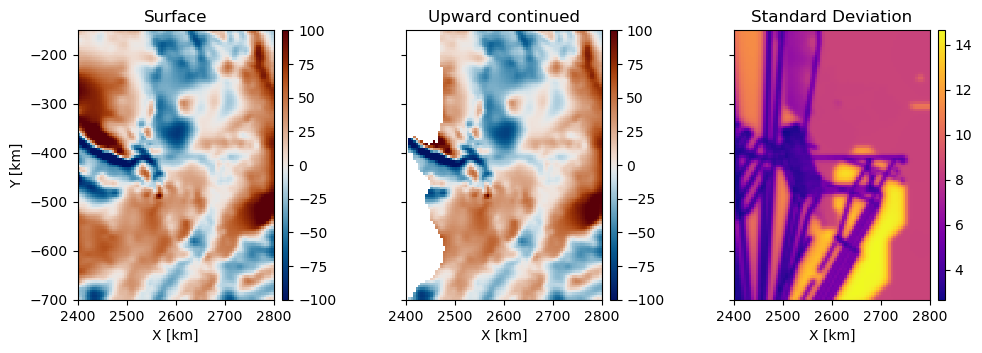

In [5]:
plot_gravity(ds, ds.grav_surface.values, ds.grav_1500.values, ds.stdev.values, 1500, (12,3.5), 100)

In [6]:
grav = pd.read_csv('shack_grav.csv')

xx, yy = np.meshgrid(ds.x.values, ds.y.values)
grav_mask = ds.surface.values < 1500

print(f'{grav.shape[0]} points')
grav.head()

7568 points


,x,y,height,faa,inv_msk,inv_pad,stdev
0,2407500.0,-697500.0,1500,-18.687181,False,False,2.926633
1,2412500.0,-697500.0,1500,-29.390454,False,False,2.972684
2,2417500.0,-697500.0,1500,-43.740359,False,False,3.574133
3,2422500.0,-697500.0,1500,-58.518576,False,False,4.569597
4,2427500.0,-697500.0,1500,-71.645276,False,False,4.135854


In [7]:
%%time

g_z = bm_terrain_effect(ds, grav)

CPU times: total: 45.5 s
Wall time: 4.04 s


In [8]:
g_z_grid = xy_into_grid(ds.x.values, ds.y.values, (grav.x.values, grav.y.values), g_z)
gdist_masked = np.where(grav_mask, ds.grav_1500.values, np.nan)
boug_grid = gdist_masked-g_z_grid

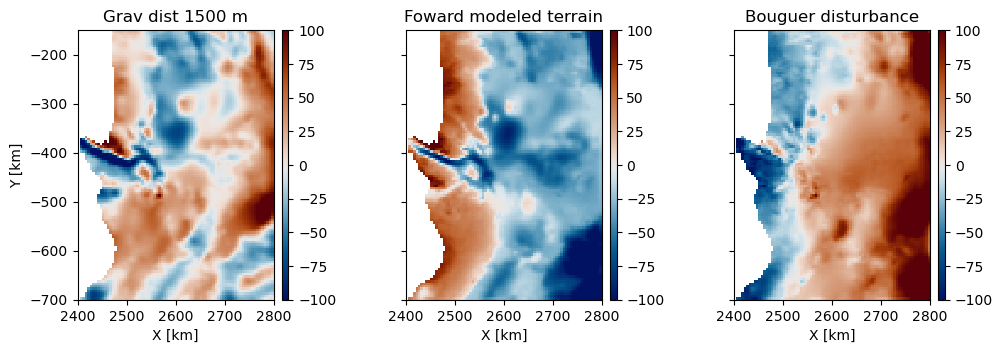

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(12,3.5), sharey=True)
ax = axs[0]
im = ax.pcolormesh(ds.x/1000, ds.y/1000, gdist_masked, cmap=cm.vik, vmin=-100, vmax=100)
ax.axis('scaled')
ax.set_title('Grav dist 1500 m')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ds.x/1000, ds.y/1000, g_z_grid, cmap=cm.vik, vmin=-100, vmax=100)
ax.axis('scaled')
ax.set_title('Foward modeled terrain')
ax.set_xlabel('X [km]')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[2]
im = ax.pcolormesh(ds.x/1000, ds.y/1000, boug_grid, cmap=cm.vik, vmin=-100, vmax=100)
ax.axis('scaled')
ax.set_title('Bouguer disturbance')
ax.set_xlabel('X [km]')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
plt.show()

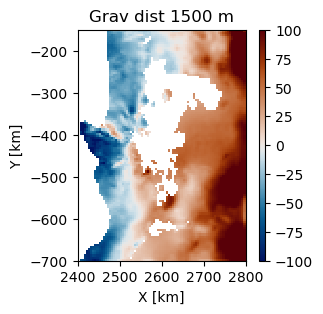

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6,3), sharey=True)
im = ax.pcolormesh(ds.x/1000, ds.y/1000, np.where(ds.inv_msk, np.nan, boug_grid), cmap=cm.vik, vmin=-100, vmax=100)
ax.axis('scaled')
ax.set_title('Grav dist 1500 m')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
plt.show()

In [11]:
boug_dist = boug_grid[grav_mask]

trend = rbf_trend(ds, grav, boug_dist, smoothing=1e10, full_grid=True)
residual_grid = boug_grid-trend

trend.shape

(110, 80)

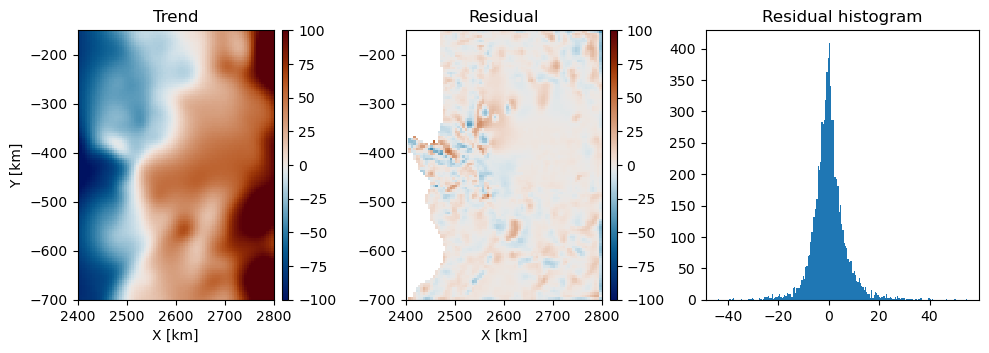

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(12,3.5), sharey=False)
ax = axs[0]
im = ax.pcolormesh(ds.x/1000, ds.y/1000, trend, cmap=cm.vik, vmin=-100, vmax=100)
ax.axis('scaled')
ax.set_title('Trend')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ds.x/1000, ds.y/1000, residual_grid, cmap=cm.vik, vmin=-100, vmax=100)
ax.axis('scaled')
ax.set_title('Residual')
ax.set_xlabel('X [km]')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[2]
ax.hist(residual_grid.flatten(), bins=200)
ax.set_title('Residual histogram')

plt.show()

In [13]:
cond_msk = (np.abs(residual_grid)<25) & (ds.inv_msk==False)
res_grid_mod = np.where(cond_msk, residual_grid, np.nan)

In [14]:
vgrams, experimental, bins = utilities.variograms(xx, yy, res_grid_mod, maxlag=30e3, n_lags=20)

In [15]:
# evaluate models
xi =np.linspace(0, bins[-1], 100) 

y_exp = models.exponential(xi, *vgrams['exponential'])
y_gauss = models.gaussian(xi, *vgrams['gaussian'])
y_sph = models.spherical(xi, *vgrams['spherical'])
y_matern = models.matern(xi, *vgrams['matern'])

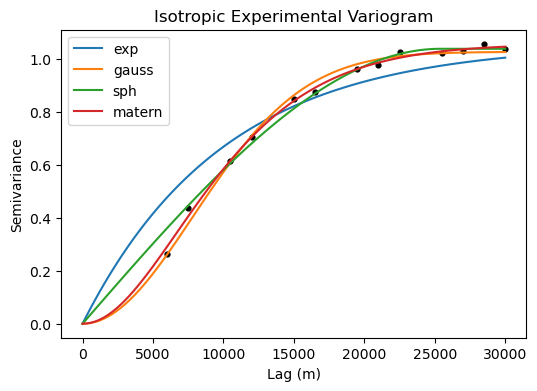

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(bins, experimental, s=12, c='k')
plt.plot(xi, y_exp, label='exp')
plt.plot(xi, y_gauss, label='gauss')
plt.plot(xi, y_sph, label='sph')
plt.plot(xi, y_matern, label='matern')
plt.title('Isotropic Experimental Variogram')
plt.xlabel('Lag (m)'); plt.ylabel('Semivariance')
plt.legend()
plt.show()

In [17]:
# random number generator
rng = np.random.default_rng(seed=0)

k = 48
rad = 500_000

parameters = vgrams['matern']

vario = {
    'azimuth' : 0,
    'nugget' : parameters[-1],
    'major_range' : parameters[0],
    'minor_range' : parameters[0],
    'sill' : parameters[1],
    'vtype' : 'matern',
    's' : parameters[2]
}

# vario = {
#     'azimuth' : 0,
#     'nugget' : parameters[-1],
#     'major_range' : parameters[0],
#     'minor_range' : parameters[0],
#     'sill' : parameters[1],
#     'vtype' : 'spherical'
# }

In [18]:
density_dict = {
    'ice' : 917,
    'water' : 1027,
    'rock' : 2670
}
min_bound, boug_max_grid = bouguer_lower_bound(ds, grav, trend, density_dict)

bounds = (min_bound, 100)

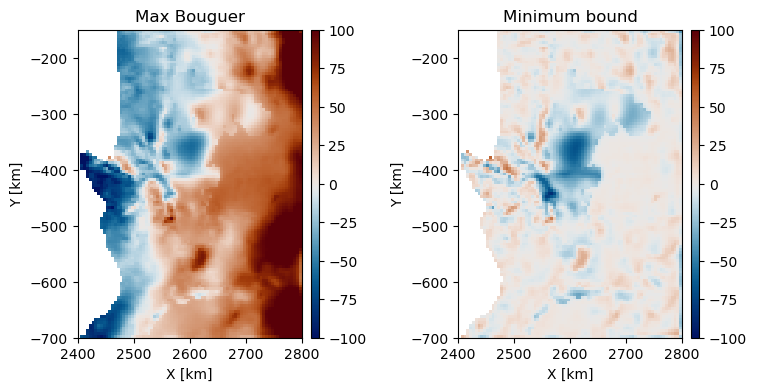

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(9,4))
ax = axs[0]
im = ax.pcolormesh(ds.x.values/1000, ds.y.values/1000, boug_max_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Max Bouguer')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ds.x.values/1000, ds.y.values/1000, min_bound, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Minimum bound')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
plt.show()

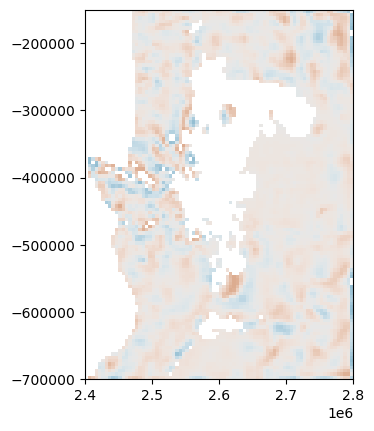

In [20]:
plt.pcolormesh(xx, yy, res_grid_mod, vmin=-100, vmax=100, cmap=cm.vik)
plt.axis('scaled')
plt.show()

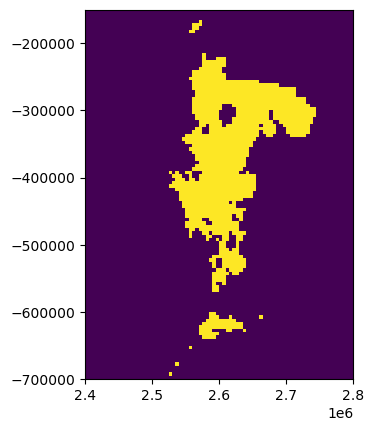

In [21]:
plt.pcolormesh(xx, yy, ds.inv_msk.values)
plt.axis('scaled')
plt.show()

In [22]:
sim1 = interpolate.sgs(xx, yy, res_grid_mod, vario, rad, k, sim_mask=ds.inv_msk.values, seed=rng, bounds=bounds)

  0%|          | 0/1239 [00:00<?, ?it/s]

In [23]:
sim2 = interpolate.sgs(xx, yy, res_grid_mod, vario, rad, k, sim_mask=ds.inv_msk.values, seed=rng, bounds=bounds)

  0%|          | 0/1239 [00:00<?, ?it/s]

In [24]:
sim3 = interpolate.sgs(xx, yy, res_grid_mod, vario, rad, k, sim_mask=ds.inv_msk.values, seed=rng, bounds=bounds)

  0%|          | 0/1239 [00:00<?, ?it/s]

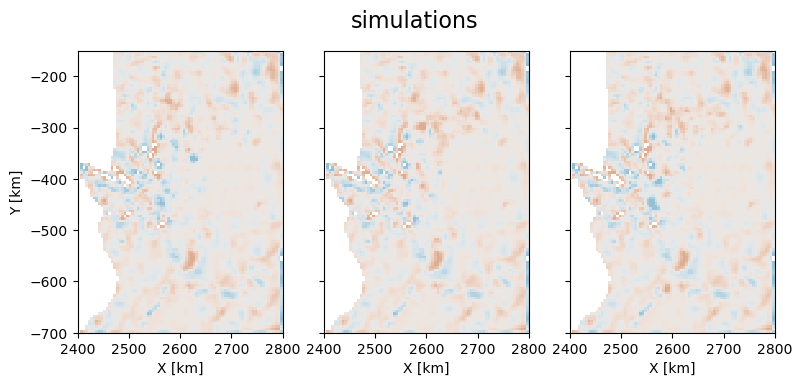

In [25]:
fig, axs = plt.subplots(1, 3, figsize=(9,4), sharey=True)

sims = [sim1, sim2, sim3]
for sim, ax in zip(sims, axs):
    ax.pcolormesh(ds.x/1000, ds.y/1000, sim, cmap=cm.vik, vmin=-100, vmax=100)
    ax.axis('scaled')

axs[0].set_ylabel('Y [km]')
axs[0].set_xlabel('X [km]')
axs[1].set_xlabel('X [km]')
axs[2].set_xlabel('X [km]')

plt.suptitle('simulations', fontsize=16, y=0.95)

plt.show()

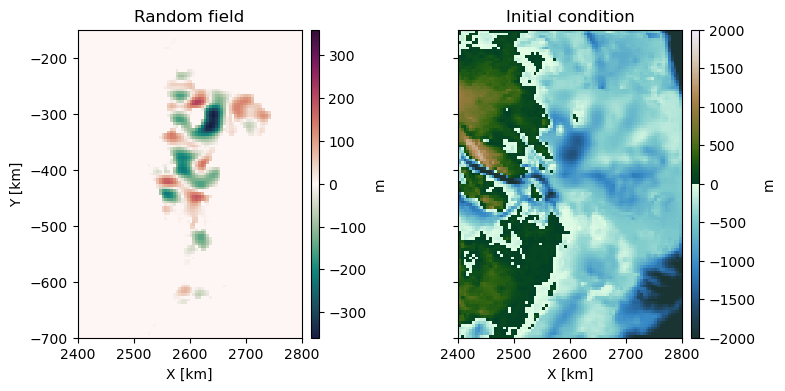

In [26]:
xkm = xx/1000
ykm = yy/1000

# make arrays for random field generation
range_max = [50e3, 50e3]
range_min = [30e3, 30e3]
high_step = 300
nug_max = 0.0
eps = 3e-4

rfgen = RFGen(ds, range_max, range_min, high_step, nug_max, eps, 'Gaussian', const_var=True, rng=rng)
field = rfgen.generate_field(condition=True)

x0 = ds.bed.values + field
x0 = np.where(x0>ds.surface-ds.thickness, ds.surface-ds.thickness, x0)

vmax = np.max(np.abs(field))

fig, axs = plt.subplots(1, 2, figsize=(9,4), sharey=True)
ax = axs[0]
im = ax.pcolormesh(xkm, ykm, field, vmax=vmax, vmin=-vmax, cmap='cmo.curl')
ax.axis('scaled')
ax.set_title('Random field')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
plt.colorbar(im, ax=ax, label='m', pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(xkm, ykm, x0, vmax=2000, vmin=-2000, cmap=cm.bukavu)
ax.axis('scaled')
ax.set_title('Initial condition')
ax.set_xlabel('X [km]')
plt.colorbar(im, ax=ax, label='m', pad=0.03, aspect=40)

plt.show()

In [27]:
density_dict = {
    'ice' : 917,
    'water' : 1027,
    'rock' : 2670
}

grav_mskd = grav[grav.inv_pad==True]
pred_coords = (grav_mskd.x.values, grav_mskd.y.values, grav_mskd.height.values)

pred_coords[0].shape

(2596,)

In [28]:
vario

{'azimuth': 0,
 'nugget': 0,
 'major_range': np.float64(24336.70372853059),
 'minor_range': np.float64(24336.70372853059),
 'sill': np.float64(1.0567315897205822),
 'vtype': 'matern',
 's': np.float64(3.1404590889172512)}

In [29]:
sim = np.where(ds.inv_msk==False, residual_grid, sim)
target = grav.faa - (sim + trend)[grav_mask]

boug_filt = filter_boug(ds, grav, target, cutoff=20e3, pad=0)
target_filt = grav.faa.values - boug_filt
target_filt = target_filt[grav.inv_pad==True]

target = target[grav.inv_pad==True]
target_grid, target_filt_grid = xy_into_grid(ds.x.values, ds.y.values, (grav_mskd.x.values, grav_mskd.y.values), (target, target_filt))

grav_mskd = grav[grav.inv_pad==True]

target.shape, grav_mskd.shape

((2596,), (2596, 7))

In [30]:
np.count_nonzero(np.isnan(target))

0

In [31]:
np.count_nonzero(np.isnan(sim))

1232

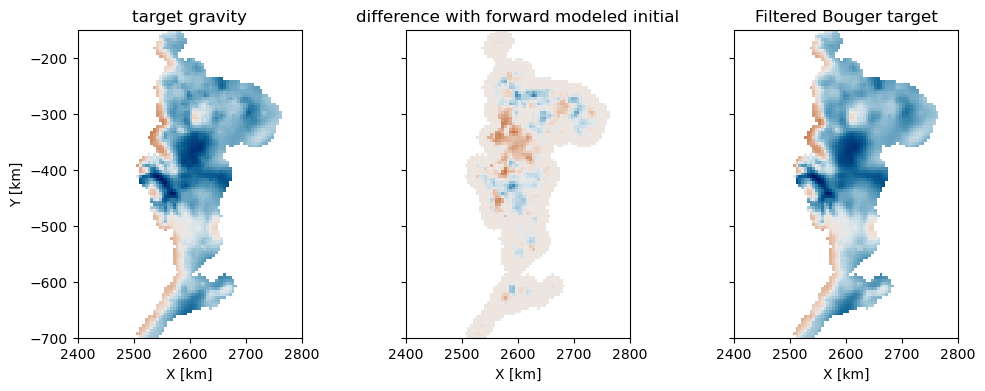

In [32]:
fig, axs = plt.subplots(1, 3, figsize=(12,4), sharey=True)
ax = axs[0]
ax.pcolormesh(xkm, ykm, target_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('target gravity')

ax = axs[1]
ax.pcolormesh(xkm, ykm, target_grid-g_z_grid, vmin=-50, vmax=50, cmap=cm.vik)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_title('difference with forward modeled initial')

ax = axs[2]
ax.pcolormesh(xkm, ykm, target_filt_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_title('Filtered Bouger target')

plt.show()

In [33]:
density_dict = {
    'ice' : 917,
    'water' : 1027,
    'rock' : 2670
}

pred_coords = (grav_mskd.x.values, grav_mskd.y.values, grav_mskd.height.values)

pred_coords[0].shape, target.shape

((2596,), (2596,))

In [34]:
# # block size, range, amplitude, iterations
# sequence = [
#     [21, 10, 60, 1000],
#     [15, 8, 40, 1000],
#     [9, 6, 40, 5000],
#     [5, 5, 40, 10000]
# ]

# # gravity uncertainty
# sigma = 1.6

sequence = [
    [21, 10, 60, 1000],
    [15, 8, 80, 1000],
    [9, 6, 100, 5000],
    [5, 5, 100, 10000]
]

# gravity uncertainty
sigma = ds.stdev.values[grav_mask][grav.inv_pad==True]

# RMSE stopping condition
stop = 3.5

# run chain sequence and time it
tic = time.time()
result = chain_sequence(sequence, ds, x0, pred_coords, target, sigma, density_dict, rng, stop=stop)
toc = time.time()
print(f'total time: {toc-tic:.1f}')

  0%|          | 0/1000 [00:00<?, ?it/s]

chain 0 efficiency: -0.063 RMSE/sec


  0%|          | 0/1000 [00:00<?, ?it/s]

chain 1 efficiency: 0.000 RMSE/sec


  0%|          | 0/5000 [00:00<?, ?it/s]

chain 2 efficiency: 0.000 RMSE/sec


  0%|          | 0/10000 [00:00<?, ?it/s]

chain 3 efficiency: 0.000 RMSE/sec
0 finished
total time: 10.0


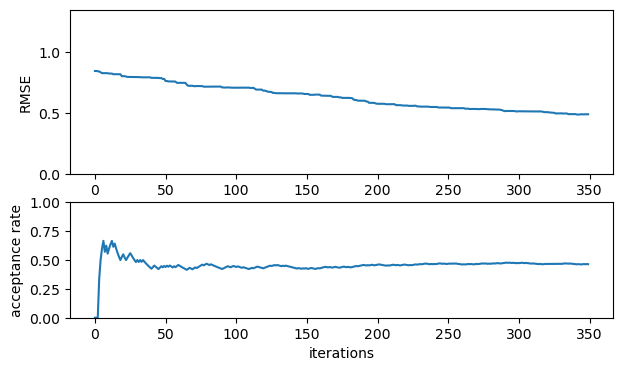

In [35]:
rmse = np.sqrt(result['loss_cache']/target.size)

fig, axs = plt.subplots(2, 1, figsize=(7,4), gridspec_kw=dict(height_ratios=[1,0.7]))
ax = axs[0]
ax.plot(rmse)
ax.set_ylim(0, np.max(rmse)+0.5)
ax.set_ylabel('RMSE')

# running acceptance rate with a 500 iteration window
run_acc = run_acceptance_rate(result['step_cache'], 500, 0)

ax = axs[1]
ax.plot(run_acc)
ax.set_xlabel('iterations')
ax.set_ylabel('acceptance rate')
ax.set_ylim(0, 1)
plt.show()

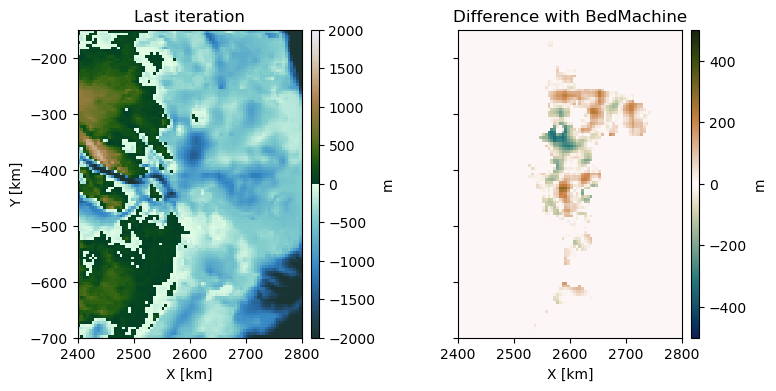

In [36]:
bed = result['bed_cache']

topo_cmap = get_topo_cm()
topo_crop = cmocean.tools.crop(cm.bukavu, np.min(bed), np.max(bed), 0)
vmin_topo = np.min(bed); vmax_topo = np.max(bed)

fig, axs = plt.subplots(1, 2, figsize=(9,4), sharey=True)

# plot last bed iteration
ax = axs[0]
im = ax.pcolormesh(xkm, ykm, bed, vmin=-2000, vmax=2000, cmap=cm.bukavu)
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Last iteration')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40, label='m')

# plot difference from BedMachine
ax = axs[1]
im = ax.pcolormesh(xkm, ykm, ds.bed-bed, vmin=-500, vmax=500, cmap='cmo.tarn_r')
ax.axis('scaled')
ax.set_xlabel('X [km]')
ax.set_title('Difference with BedMachine')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40, label='m')
plt.show()

In [37]:
target_grid, grav_result_grid = xy_into_grid(ds.x.values, ds.y.values, (pred_coords[0], pred_coords[1]), 
                                             (target, result['grav_cache']), quiet=True)

grav_residual_grid = target_grid - grav_result_grid

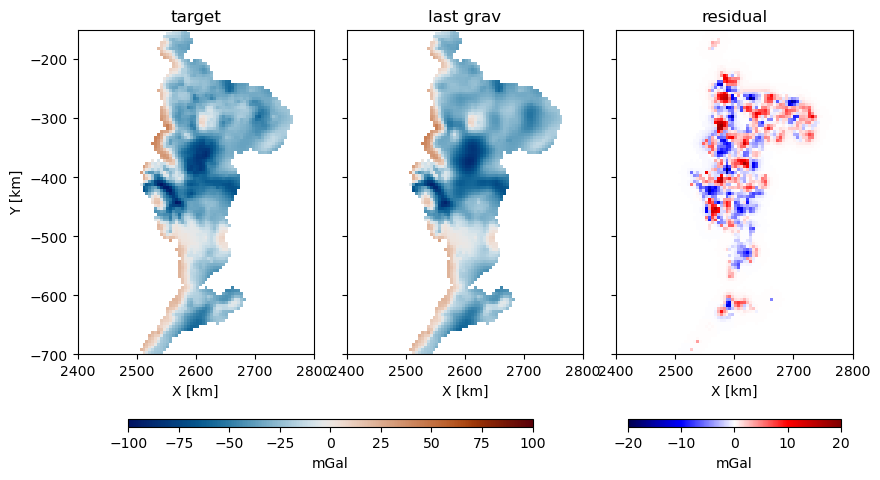

In [38]:
#fig, axs = plt.subplots(1, 3, figsize=(15,5), sharey=True)

fig = plt.figure(figsize=(10,5.5))
gridspec = GridSpec(2, 3, height_ratios=[1, 0.02], wspace=0.14)

ax1 = fig.add_subplot(gridspec[0,0])
ax2 = fig.add_subplot(gridspec[0,1])
ax3 = fig.add_subplot(gridspec[0,2])

ax = ax1
im = ax.pcolormesh(xkm, ykm, target_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_title('target')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')

ax = ax2
im = ax.pcolormesh(xkm, ykm, grav_result_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_title('last grav')
ax.set_xlabel('X [km]')
ax.set_yticklabels([])

gs2 = GridSpecFromSubplotSpec(1, 100, gridspec[1,:2])
cax = fig.add_subplot(gs2[10:90])
plt.colorbar(im, cax=cax, label='mGal', orientation='horizontal')

ax = ax3
im = ax.pcolormesh(xkm, ykm, grav_residual_grid, vmin=-20, vmax=20, cmap='seismic')
ax.axis('scaled')
ax.set_title('residual')
ax.set_xlabel('X [km]')
ax.set_yticklabels([])

gs3 = GridSpecFromSubplotSpec(1, 100, gridspec[1,2])
cax = fig.add_subplot(gs3[5:95])
plt.colorbar(im, cax=cax, label='mGal', orientation='horizontal')
plt.show()

In [39]:
bed_filt = lowpass_filter_invpad(ds, bed, cutoff=10e3)
bed_filt = bed_filt.reshape(bed.shape)
bed_high = bed-bed_filt

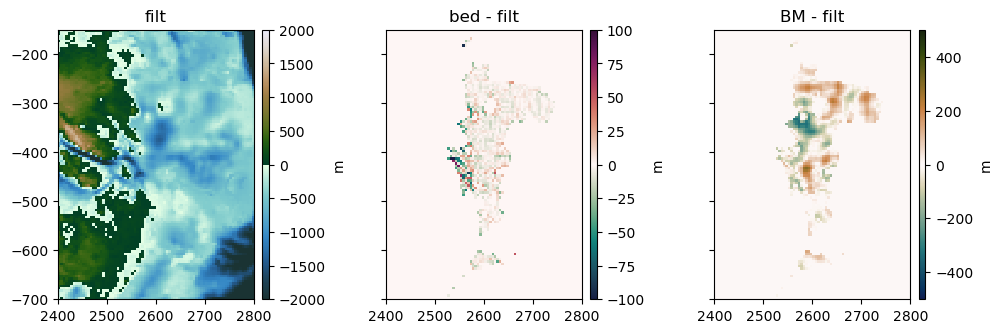

In [40]:
fig, axs = plt.subplots(1, 3, figsize=(12,3.5), sharey=True)
ax = axs[0]
im = ax.pcolormesh(xkm, ykm, bed_filt, vmin=-2000, vmax=2000, cmap=cm.bukavu)
ax.axis('scaled')
ax.set_title('filt')
plt.colorbar(im, pad=0.03, aspect=40, ax=ax, label='m')

ax = axs[1]
im = ax.pcolormesh(xkm, ykm, bed-bed_filt, vmin=-100, vmax=100, cmap='cmo.curl')
ax.axis('scaled')
ax.set_title('bed - filt')
plt.colorbar(im, pad=0.03, aspect=40, ax=ax, label='m')

ax = axs[2]
im = ax.pcolormesh(xkm, ykm, ds.bed-bed_filt, vmin=-500, vmax=500, cmap='cmo.tarn_r')
ax.axis('scaled')
ax.set_title('BM - filt')
plt.colorbar(im, pad=0.03, aspect=40, ax=ax, label='m')
plt.show()

In [41]:
prisms, densities = make_prisms(ds, bed_filt, density_dict)
g_z = hm.prism_gravity(pred_coords, prisms, densities, field='g_z')

In [42]:
np.sqrt(np.mean(np.square(target-g_z)))

np.float64(3.4465586768219505)

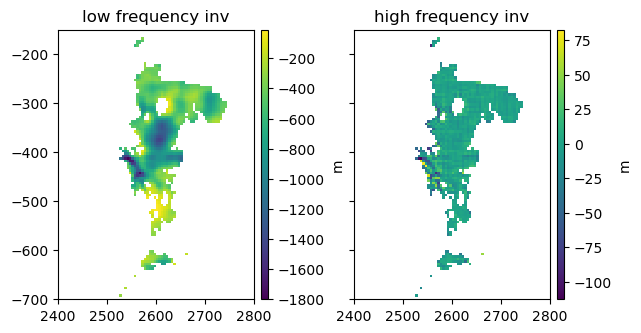

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(7,3.5), sharey=True)

ax = axs[0]
im = ax.pcolormesh(xkm, ykm, np.where(ds.inv_msk, bed_filt, np.nan))
ax.axis('scaled')
ax.set_title('low frequency inv')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40, label='m')

ax = axs[1]
im = ax.pcolormesh(xkm, ykm, np.where(ds.inv_msk, bed_high, np.nan))
ax.axis('scaled')
ax.set_title('high frequency inv')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40, label='m')
plt.show()

# Gauss-Newton method

In [44]:
bed_cache, rmse_cache = gauss_newton(ds, target_filt, pred_coords, density_dict, max_iter=30, alpha=0.2, perturb_scale=1, lamb=0.00, stop=0.001, quiet=False)

# start 	 RMSE: 4.242
# 1 	 RMSE: 3.395 	 time elapsed: 3.57 s
# 2 	 RMSE: 2.735 	 time elapsed: 5.57 s
# 3 	 RMSE: 2.223 	 time elapsed: 7.72 s
# 4 	 RMSE: 1.827 	 time elapsed: 9.80 s
# 5 	 RMSE: 1.525 	 time elapsed: 11.79 s
# 6 	 RMSE: 1.300 	 time elapsed: 13.84 s
# 7 	 RMSE: 1.136 	 time elapsed: 15.87 s
# 8 	 RMSE: 1.020 	 time elapsed: 17.98 s
# 9 	 RMSE: 0.941 	 time elapsed: 20.04 s
# 10 	 RMSE: 0.889 	 time elapsed: 22.10 s
# 11 	 RMSE: 0.855 	 time elapsed: 24.13 s
# 12 	 RMSE: 0.834 	 time elapsed: 26.11 s
# 13 	 RMSE: 0.822 	 time elapsed: 28.21 s
# 14 	 RMSE: 0.814 	 time elapsed: 30.43 s
# 15 	 RMSE: 0.810 	 time elapsed: 32.81 s
# 16 	 RMSE: 0.807 	 time elapsed: 34.85 s
# 17 	 RMSE: 0.806 	 time elapsed: 36.93 s
# 18 	 RMSE: 0.806 	 time elapsed: 39.08 s
reached stopping criterion after 18 iterations


In [45]:
ds.bed.values[ds.inv_msk.values==True].size, grav_mskd.shape[0]

(1239, 2596)

In [46]:
bed_cache.shape

(19, 110, 80)

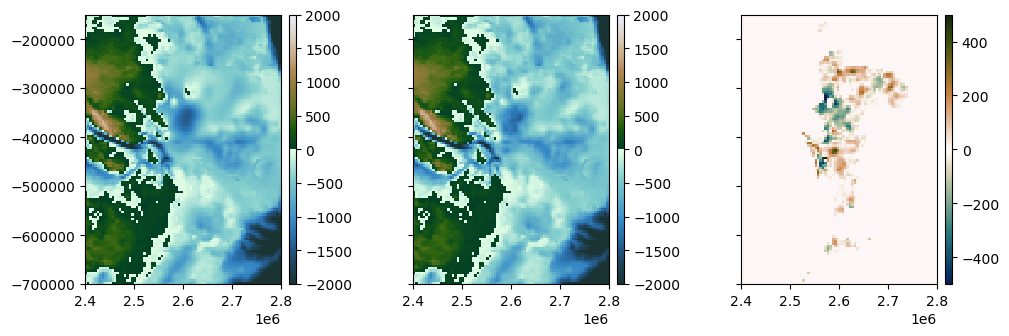

In [47]:
index = -1

fig, axs = plt.subplots(1, 3, figsize=(12,3.5), sharey=True)

ax = axs[0]
im = ax.pcolormesh(ds.x, ds.y, ds.bed, cmap=cm.bukavu, vmin=-2000, vmax=2000)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ds.x, ds.y, bed_cache[index,...], cmap=cm.bukavu, vmin=-2000, vmax=2000)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[2]
im = ax.pcolormesh(ds.x, ds.y, ds.bed-bed_cache[index,...], cmap='cmo.tarn_r', vmin=-500, vmax=500)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
plt.show()

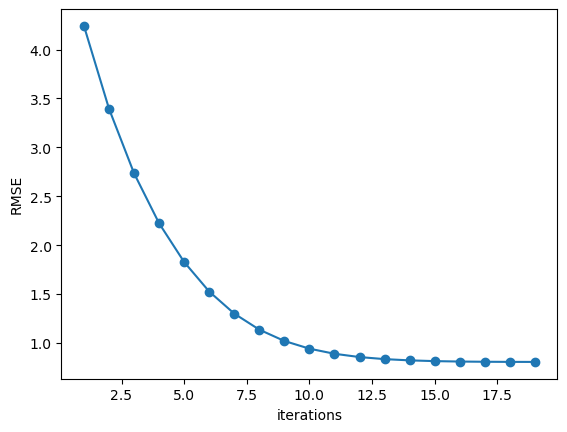

In [48]:
plt.plot(np.arange(1, rmse_cache.size+1), rmse_cache, 'o-')
plt.xlabel('iterations')
plt.ylabel('RMSE')
plt.show()

In [49]:
prisms, densities = make_prisms(ds, bed_cache[-1,...], density_dict)
g_z_new = hm.prism_gravity(pred_coords, prisms, densities, field='g_z')

target_grid, grav_result_grid = xy_into_grid(ds.x.values, ds.y.values, (pred_coords[0], pred_coords[1]), 
                                             (target_filt, g_z_new), quiet=True)

grav_residual_grid = target_grid - grav_result_grid

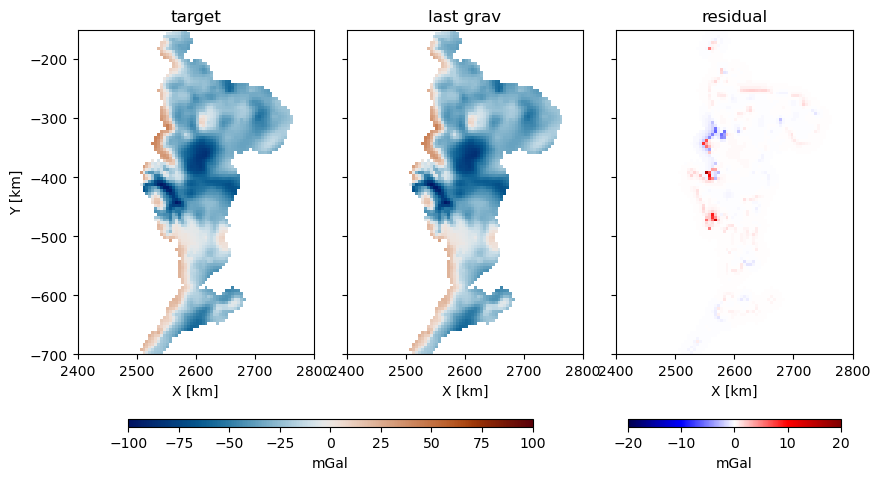

In [50]:
xkm = ds.x.values/1000
ykm = ds.y.values/1000

fig = plt.figure(figsize=(10,5.5))
gridspec = GridSpec(2, 3, height_ratios=[1, 0.02], wspace=0.14)

ax1 = fig.add_subplot(gridspec[0,0])
ax2 = fig.add_subplot(gridspec[0,1])
ax3 = fig.add_subplot(gridspec[0,2])

ax = ax1
im = ax.pcolormesh(xkm, ykm, target_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_title('target')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')

ax = ax2
im = ax.pcolormesh(xkm, ykm, grav_result_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_title('last grav')
ax.set_xlabel('X [km]')
ax.set_yticklabels([])

gs2 = GridSpecFromSubplotSpec(1, 100, gridspec[1,:2])
cax = fig.add_subplot(gs2[10:90])
plt.colorbar(im, cax=cax, label='mGal', orientation='horizontal')

ax = ax3
im = ax.pcolormesh(xkm, ykm, grav_residual_grid, vmin=-20, vmax=20, cmap='seismic')
ax.axis('scaled')
ax.set_title('residual')
ax.set_xlabel('X [km]')
ax.set_yticklabels([])

gs3 = GridSpecFromSubplotSpec(1, 100, gridspec[1,2])
cax = fig.add_subplot(gs3[5:95])
plt.colorbar(im, cax=cax, label='mGal', orientation='horizontal')
plt.show()

In [51]:
np.sqrt(np.mean(np.square(target_filt - g_z_new)))

np.float64(0.8057299186661327)

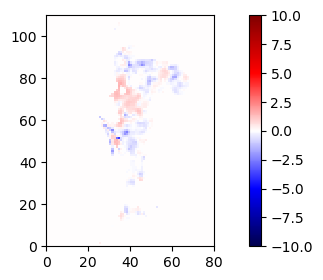

In [52]:
plt.figure(figsize=(9,3))
plt.pcolormesh(bed_cache[-1,...]-bed_cache[-2,...], vmin=-10, vmax=10, cmap='seismic')
plt.axis('scaled')
plt.colorbar()
plt.show()

In [53]:
lapop = make_laplace(ds.bed.values)
lapop_trim = trim_laplace(lapop, ds.inv_pad.values)

Wm = lapop_trim
Cm = Wm.T@Wm

stdev = ds.stdev.values[grav_mask & ds.inv_pad.values]
weights = 1/stdev**2

Wd = np.diag(weights)

prior = ds.bed.values.astype(np.float64)

In [54]:
lambdas = np.concatenate([[1e-3, 1e-4], np.logspace(-5, -9, num=10), [1e-10, 1e-11]])
data_fits = []
model_fits = []

lopt, data_fits, model_fits, dists = lcurve(lambdas, ds, prior, target, pred_coords, density_dict, Cm, Wd, max_iter=30, alpha=0.5, perturb_scale=1, stop=0.01, quiet=True)

  0%|          | 0/14 [00:00<?, ?it/s]

In [55]:
print(f'optimal lambda: {lopt:.2e}')

optimal lambda: 1.67e-07


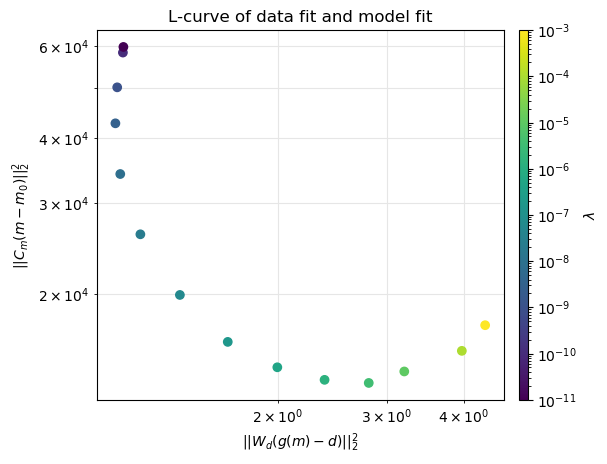

In [56]:
from matplotlib import colors

fig, ax = plt.subplots(1, 1)
im = ax.scatter(data_fits, model_fits, c=lambdas, norm=colors.LogNorm(), zorder=9999)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$||W_d(g(m)-d)||_{2}^{2}$')
ax.set_ylabel(r'$||C_m(m-m_0)||_{2}^{2}$')
ax.set_title('L-curve of data fit and model fit')
ax.grid()
ax.grid(which="minor", color="0.9")
plt.colorbar(im, pad=0.03, aspect=40, label=r'$\lambda$')
plt.show()

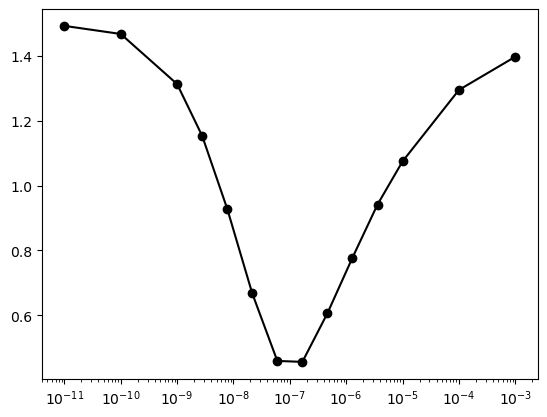

In [57]:
fig, ax = plt.subplots(1, 1)
ax.plot(lambdas, dists, 'ko-')
ax.set_xscale('log')
plt.show()

In [58]:
lopt

np.float64(1.668100537200059e-07)

In [59]:
bed_cache, rmse_cache = gauss_newton_regularized(ds, prior, target, pred_coords, density_dict, Cm, Wd, max_iter=30, alpha='search', perturb_scale=1, lamb=lopt, stop=0.001, quiet=False)

# start 	 RMSE: 4.609
# 1 	 RMSE: 1.642 	 time elapsed: 7.28 s
# 2 	 RMSE: 1.611 	 time elapsed: 12.73 s
# 3 	 RMSE: 1.599 	 time elapsed: 17.94 s
# 4 	 RMSE: 1.593 	 time elapsed: 23.36 s
# 5 	 RMSE: 1.590 	 time elapsed: 28.65 s
# 6 	 RMSE: 1.588 	 time elapsed: 33.01 s
# 7 	 RMSE: 1.588 	 time elapsed: 38.38 s
reached stopping criterion after 7 iterations


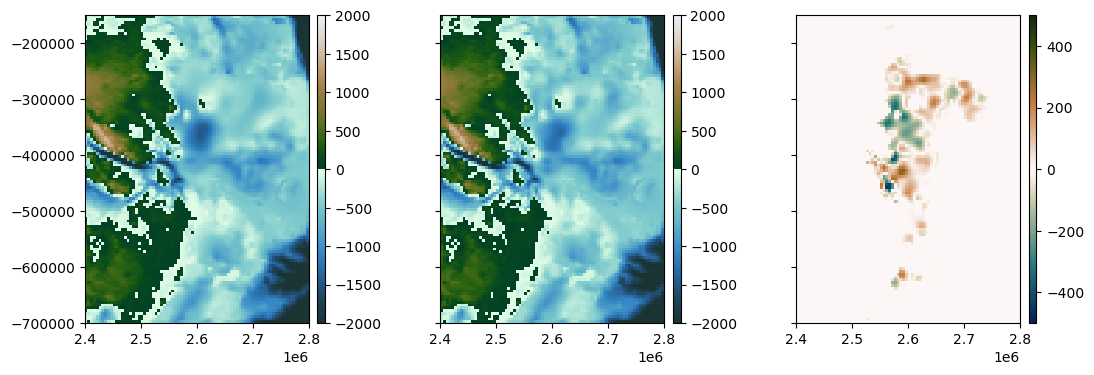

In [60]:
index = -1

fig, axs = plt.subplots(1, 3, figsize=(13,4), sharey=True)

ax = axs[0]
im = ax.pcolormesh(ds.x, ds.y, ds.bed, cmap=cm.bukavu, vmin=-2000, vmax=2000)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ds.x, ds.y, bed_cache[index,...], cmap=cm.bukavu, vmin=-2000, vmax=2000)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[2]
im = ax.pcolormesh(ds.x, ds.y, ds.bed-bed_cache[index,...], cmap='cmo.tarn_r', vmin=-500, vmax=500)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
plt.show()

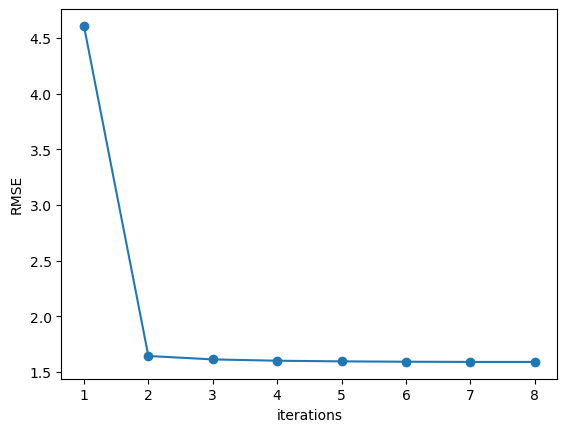

In [61]:
plt.plot(np.arange(1, rmse_cache.size+1), rmse_cache, 'o-')
plt.xlabel('iterations')
plt.ylabel('RMSE')
plt.show()

In [62]:
prisms, densities = make_prisms(ds, bed_cache[-1,...], density_dict)
g_z_new = hm.prism_gravity(pred_coords, prisms, densities, field='g_z')

target_grid, grav_result_grid = xy_into_grid(ds.x.values, ds.y.values, (pred_coords[0], pred_coords[1]), 
                                             (target, g_z_new))

grav_residual_grid = target_grid - grav_result_grid

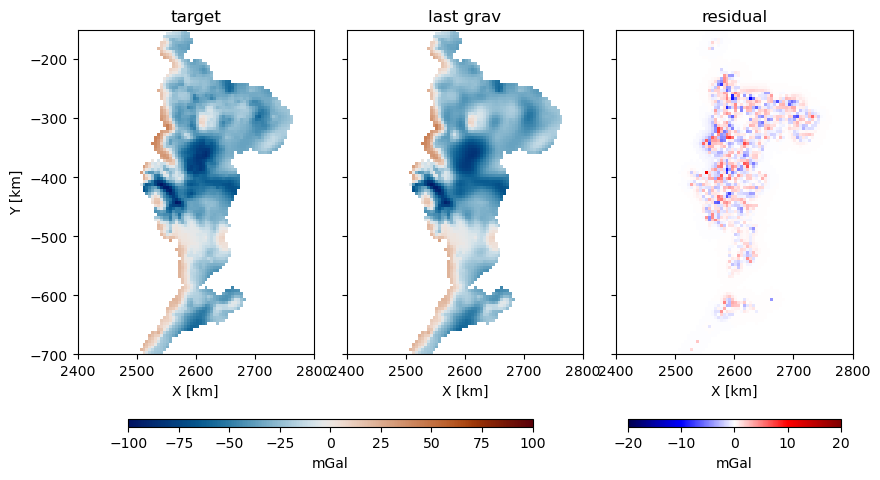

In [63]:
xkm = ds.x.values/1000
ykm = ds.y.values/1000

fig = plt.figure(figsize=(10,5.5))
gridspec = GridSpec(2, 3, height_ratios=[1, 0.02], wspace=0.14)

ax1 = fig.add_subplot(gridspec[0,0])
ax2 = fig.add_subplot(gridspec[0,1])
ax3 = fig.add_subplot(gridspec[0,2])

ax = ax1
im = ax.pcolormesh(xkm, ykm, target_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_title('target')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')

ax = ax2
im = ax.pcolormesh(xkm, ykm, grav_result_grid, vmin=-100, vmax=100, cmap=cm.vik)
ax.axis('scaled')
ax.set_title('last grav')
ax.set_xlabel('X [km]')
ax.set_yticklabels([])

gs2 = GridSpecFromSubplotSpec(1, 100, gridspec[1,:2])
cax = fig.add_subplot(gs2[10:90])
plt.colorbar(im, cax=cax, label='mGal', orientation='horizontal')

ax = ax3
im = ax.pcolormesh(xkm, ykm, grav_residual_grid, vmin=-20, vmax=20, cmap='seismic')
ax.axis('scaled')
ax.set_title('residual')
ax.set_xlabel('X [km]')
ax.set_yticklabels([])

gs3 = GridSpecFromSubplotSpec(1, 100, gridspec[1,2])
cax = fig.add_subplot(gs3[5:95])
plt.colorbar(im, cax=cax, label='mGal', orientation='horizontal')
plt.show()